# Red or Green, What Coloured Cat Food does Mi Prefer?

**Statistical analysis of cat food colour preference using a chi-squared goodness-of-fit test.**

This notebook walks through the full analysis pipeline:
1. Load and inspect the raw data
2. Visualize the preference counts
3. Perform a chi-squared goodness-of-fit test
4. Interpret the results

## 1. Setup and Data Loading

The raw experimental data was recorded by hand on paper data sheets over 30 days (August–September 2024). Each day, Mi was presented with two bowls of kibble — one dyed red, one dyed green — and the colour he approached first was recorded as his preference for that day. Days where Mi did not eat from either bowl were excluded.

The preference tallies were transcribed from the handwritten records into `catfood_summary.csv`. The original data sheets are photographed in `DATA/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load the summary data
df = pd.read_csv('catfood_summary.csv')
print(df)
print(f"\nTotal days with a preference: {df['days_preferred'].sum()}")

Matplotlib is building the font cache; this may take a moment.


  colour  days_preferred
0    red              13
1  green              17

Total days with a preference: 30


## 2. Visualization

Let's visualize the preference distribution with a bar chart and a pie chart.

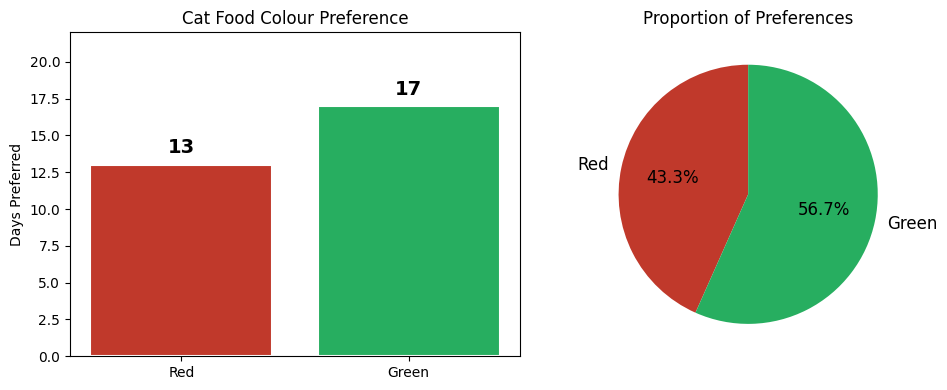

Figures saved to catfood_preference.png and catfood_preference.svg


In [2]:
colours = ['#c0392b', '#27ae60']
labels = df['colour'].str.capitalize()
values = df['days_preferred']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = ax1.bar(labels, values, color=colours, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Days Preferred')
ax1.set_title('Cat Food Colour Preference')
ax1.set_ylim(0, max(values) + 5)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontweight='bold', fontsize=14)

# Pie chart
ax2.pie(values, labels=labels, colors=colours, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 12})
ax2.set_title('Proportion of Preferences')

plt.tight_layout()
plt.savefig('catfood_preference.png', dpi=300, bbox_inches='tight')
plt.savefig('catfood_preference.svg', bbox_inches='tight')
plt.show()
print('Figures saved to catfood_preference.png and catfood_preference.svg')

## 3. Chi-Squared Goodness-of-Fit Test

### Hypotheses

- **Null hypothesis (H₀):** Mi has no colour preference — he is equally likely to choose red or green (expected: 15 each).
- **Alternative hypothesis (H₁):** Mi has a colour preference — the observed counts differ significantly from 50/50.

### Test Parameters

- **Significance level:** α = 0.05
- **Degrees of freedom:** k − 1 = 2 − 1 = 1
- **Critical value:** χ²₀.₀₅,₁ = 3.841

In [3]:
# Observed and expected frequencies
observed = np.array(values)
total = observed.sum()
expected = np.array([total / 2, total / 2])  # equal preference = 15 each

print(f'Observed:  Red = {observed[0]}, Green = {observed[1]}')
print(f'Expected:  Red = {expected[0]:.0f}, Green = {expected[1]:.0f}')
print(f'Total days: {total}')

Observed:  Red = 13, Green = 17
Expected:  Red = 15, Green = 15
Total days: 30


In [4]:
# Manual calculation (matching the written report)
chi2_manual = np.sum((observed - expected)**2 / expected)
print(f'Chi-squared (manual): {chi2_manual:.3f}')
print()

# Show the calculation step by step
print('Step-by-step:')
for colour, obs, exp in zip(['Red', 'Green'], observed, expected):
    component = (obs - exp)**2 / exp
    print(f'  {colour}: ({obs} - {exp:.0f})² / {exp:.0f} = {component:.3f}')
print(f'  Total: {chi2_manual:.3f}')

Chi-squared (manual): 0.533

Step-by-step:
  Red: (13 - 15)² / 15 = 0.267
  Green: (17 - 15)² / 15 = 0.267
  Total: 0.533


In [5]:
# SciPy verification
chi2_stat, p_value = stats.chisquare(observed, f_exp=expected)

alpha = 0.05
critical_value = stats.chi2.ppf(1 - alpha, df=1)

print(f'Chi-squared statistic: {chi2_stat:.3f}')
print(f'p-value:               {p_value:.4f}')
print(f'Critical value (95%):  {critical_value:.3f}')
print(f'Degrees of freedom:    1')
print()
print(f'Test: {chi2_stat:.3f} < {critical_value:.3f}?  {"✅ Yes" if chi2_stat < critical_value else "❌ No"}')
print(f'p-value {p_value:.4f} > {alpha}?  {"✅ Yes" if p_value > alpha else "❌ No"}')

Chi-squared statistic: 0.533
p-value:               0.4652
Critical value (95%):  3.841
Degrees of freedom:    1

Test: 0.533 < 3.841?  ✅ Yes
p-value 0.4652 > 0.05?  ✅ Yes


## 4. Visualize the Test

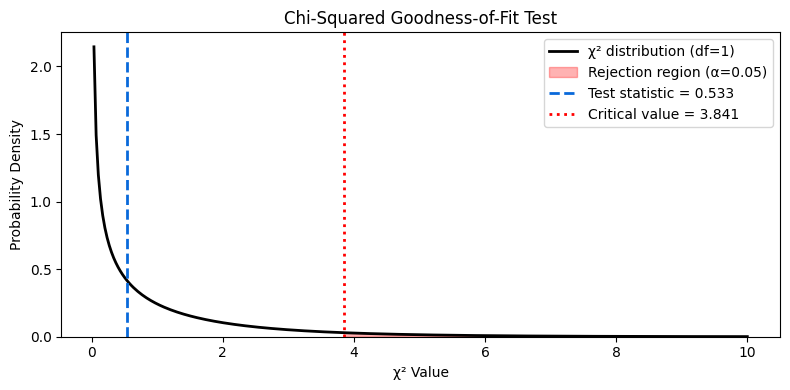

Figures saved to catfood_chi2_test.png and catfood_chi2_test.svg


In [6]:
# Plot the chi-squared distribution with test statistic and critical value
x = np.linspace(0, 10, 300)
y = stats.chi2.pdf(x, df=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x, y, 'k-', linewidth=2, label='χ² distribution (df=1)')

# Shade the rejection region
x_reject = np.linspace(critical_value, 10, 200)
ax.fill_between(x_reject, stats.chi2.pdf(x_reject, df=1),
                alpha=0.3, color='red', label=f'Rejection region (α=0.05)')

# Mark the test statistic
ax.axvline(chi2_stat, color='#0969da', linewidth=2, linestyle='--',
           label=f'Test statistic = {chi2_stat:.3f}')

# Mark the critical value
ax.axvline(critical_value, color='red', linewidth=2, linestyle=':',
           label=f'Critical value = {critical_value:.3f}')

ax.set_xlabel('χ² Value')
ax.set_ylabel('Probability Density')
ax.set_title('Chi-Squared Goodness-of-Fit Test')
ax.legend(loc='upper right')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('catfood_chi2_test.png', dpi=300, bbox_inches='tight')
plt.savefig('catfood_chi2_test.svg', bbox_inches='tight')
plt.show()
print('Figures saved to catfood_chi2_test.png and catfood_chi2_test.svg')

## 5. Conclusion

The chi-squared test statistic (0.267) is well below the critical value (3.841) at the 95% confidence level. The p-value is large, indicating no significant evidence against the null hypothesis.

**We fail to reject the null hypothesis.** There is no statistically significant evidence that Mi prefers one colour over the other. Mi appears to enjoy his cat food equally whether it is dyed red or green.